In [1]:
# ── Mount Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Point Python at your project files ───────────────────────
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)           # so   import feature_engineering   works
os.chdir(PROJECT)                     # so   Path("../data/...")   resolves
print(f"Working dir: {os.getcwd()}")

Mounted at /content/drive
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [2]:
 %%capture
 !pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [3]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy onnxscript

# Notebook 03 — Layer 2A Experiments
Train Isolation Forest and Shallow Autoencoder. Compare on FPR / TPR / AUC. Export winner to ONNX.

In [4]:
#!cat layer2a/candidates/autoencoder_shallow.py



In [5]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import mlflow
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve

from feature_engineering.normalizer import Normalizer
from layer2a.candidates.isolation_forest import IsolationForestModel
# FIX: remove "ml." prefix — sys.path already points inside ml/
from layer2a.candidates.autoencoder_shallow import ShallowAutoencoderModel
from layer2a.evaluate import evaluate_candidate, pick_best, threshold_sweep
from evaluation.compare_models import compare_l2a, pick_best_l2a
from evaluation.benchmark import benchmark_isolation_forest, benchmark_autoencoder

SPLITS  = Path("../data/splits")
EXPORTS = Path("../exported_models")
EXPORTS.mkdir(exist_ok=True)


## 1. Load splits

In [6]:
X_n_train    = np.load(SPLITS / "l2a_normal_train.npy")
X_n_val      = np.load(SPLITS / "l2a_normal_val.npy")
X_attack_val = np.load(SPLITS / "l2a_attack_val.npy")
X_test       = np.load(SPLITS / "l2a_test_X.npy")
y_test       = np.load(SPLITS / "l2a_test_y.npy")

norm         = Normalizer.load(str(EXPORTS / "scaler_l2a.pkl"))
X_train      = norm.transform(X_n_train)
X_val        = norm.transform(X_n_val)
X_atk_val    = norm.transform(X_attack_val)
X_te         = norm.transform(X_test)

print(f"Train  (normal only):  {X_train.shape}")
print(f"Val    (normal only):  {X_val.shape}     ← FPR measured here")
print(f"Val    (attack only):  {X_atk_val.shape}  ← TPR measured here")
print(f"Test   (mixed):        {X_te.shape}  attack_rate={y_test.mean():.1%}")


[Normalizer] Loaded from ../exported_models/scaler_l2a.pkl
Train  (normal only):  (3500, 25)
Val    (normal only):  (750, 25)     ← FPR measured here
Val    (attack only):  (4666, 25)  ← TPR measured here
Test   (mixed):        (5416, 25)  attack_rate=86.2%


## 2. Candidate 1 — Isolation Forest

In [7]:
mlflow.set_experiment("layer2a")
iforest = IsolationForestModel()
iforest.train(X_train)

# FIX: pass normal val + attack val SEPARATELY
# iforest.tune_threshold internally:
#   FPR = FP/(FP+TN) on X_val (normal only)
#   TPR = TP/(TP+FN) on X_atk_val (attack only)
iforest.tune_threshold(
    X_normal_val = X_val,
    X_attack_val = X_atk_val,
    target_fpr   = 0.05,
)

res_iforest = evaluate_candidate(iforest, X_te, y_test, name="isolation_forest")
print(res_iforest)


2026/04/03 07:21:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 07:21:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[IForest] Trained on 3,500 normal samples.
[IForest] Normal score distribution on training set:
  P50=-0.14387  P99=0.04685
[IForest] Threshold sweep: [-0.14387 … 0.03977]
  (val normal P50=-0.14387, P99=0.03977)
  Attack scores: min=-0.25188  mean=-0.00624  max=0.12864
  14.8% of attacks already score above normal P99 — these are easily detected at any threshold ≤ P99.
[IForest] Tuned threshold = 0.002603
  Val normal  → FPR=0.0493  (FP=37, TN=713)  target≤0.05
  Val attacks → TPR=0.3663  (TP=1709, FN=2957)

[evaluate] isolation_forest
  auc                   : 0.9293
  avg_precision         : 0.9842
  fpr                   : 0.032
  tpr                   : 0.3701
  tp                    : 1727
  fp                    : 24
  tn                    : 726
  fn                    : 2939
{'model': 'isolation_forest', 'auc': 0.9293, 'avg_precision': 0.9842, 'fpr': 0.032, 'tpr': 0.3701, 'tp': 1727, 'fp': 24, 'tn': 726, 'fn': 2939}


## 3. Candidate 2 — Shallow Autoencoder

In [36]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, average_precision_score

# --- THE FIX: Outlier Removal ---
# We exclude indices 816 and 1341 which were identified as 'nuclear' outliers
# dragging the threshold to an insane 0.44.
mask = np.ones(len(X_train), dtype=bool)
mask[[816, 1341]] = False
X_train_clean = X_train[mask]

# 1. Initialize the Wrapper Class
ae = ShallowAutoencoderModel()

# 2. Call the .train() method using the CLEANED data
# This will result in a much saner threshold (~0.06) and better detection.
ae.train(X_train_clean, X_val, run_name="l2a_autoencoder_v2_cleaned")

# 3. Use the wrapper's .predict() and .anomaly_scores() for evaluation
# We test on X_te (which contains the attacks we want to catch)
scores = ae.anomaly_scores(X_te)
preds = ae.predict(X_te)

# Calculate metrics
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
auc = roc_auc_score(y_test, scores)
avg_p = average_precision_score(y_test, scores)

# Calculate FPR and TPR safely
fpr_val = round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0
tpr_val = round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0

res_ae = {
    "model": "shallow_autoencoder",
    "auc": round(auc, 4),
    "avg_precision": round(avg_p, 4),
    "fpr": fpr_val,
    "tpr": tpr_val,
    "tp": tp,
    "fp": fp,
    "tn": tn,
    "fn": fn
}

print(f"New Sane Threshold: {ae.threshold}")
print(res_ae)

[AE] Training on cpu
  epoch  10 | train=0.07789 | val=0.02737
  epoch  20 | train=0.05729 | val=0.01830
  epoch  30 | train=0.04852 | val=0.01543
  epoch  40 | train=0.04419 | val=0.01471
  epoch  50 | train=0.04617 | val=0.01408
[AE] Early stopping at epoch 56
[AE] Normal score distribution on training set:
  mean=0.01154  std=0.02795  P50=0.00333  P99=0.13256
[AE] Initial threshold (unsupervised) = 0.081408
[AE] Call tune_threshold() to refine using labelled val splits.
New Sane Threshold: 0.08140762150287628
{'model': 'shallow_autoencoder', 'auc': np.float64(0.9832), 'avg_precision': np.float64(0.9974), 'fpr': np.float64(0.0227), 'tpr': np.float64(0.9233), 'tp': np.int64(4308), 'fp': np.int64(17), 'tn': np.int64(733), 'fn': np.int64(358)}


## 4. Compare candidates

In [37]:
all_results = [res_iforest, res_ae]
df_compare = compare_l2a(all_results)
df_compare


=== Layer 2A Model Comparison ===
              Model    AUC  Avg Precision  TPR (recall)    FPR   TP  FP  TN   FN
shallow_autoencoder 0.9832         0.9974        0.9233 0.0227 4308  17 733  358
   isolation_forest 0.9293         0.9842        0.3701 0.0320 1727  24 726 2939


,Model,AUC,Avg Precision,TPR (recall),FPR,TP,FP,TN,FN
1,shallow_autoencoder,0.9832,0.9974,0.9233,0.0227,4308,17,733,358
0,isolation_forest,0.9293,0.9842,0.3701,0.0320,1727,24,726,2939


## 5. Pick winner and export ONNX

In [38]:
winner_name, winner_model = pick_best_l2a(
    all_results,
    models={"isolation_forest": iforest, "shallow_autoencoder": ae},
)
print(f"Winner: {winner_name}")

onnx_path = str(EXPORTS / "layer2a_best.onnx")
winner_model.export_onnx(onnx_path)
results_path = EXPORTS / "l2a_results.json"

def to_jsonable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

with open(results_path, "w") as f:
    json.dump(
        {"results": all_results, "winner": winner_name},
        f,
        indent=2,
        default=to_jsonable
    )

print(f"[train] Results saved → {results_path}")


/content/drive/MyDrive/waf-ml-project/ml/layer2a/candidates/autoencoder_shallow.py:379: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0403 07:41:19.590000 4038 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features



[compare] L2A Winner: shallow_autoencoder  FPR=0.0227  TPR=0.9233  AUC=0.9832
Winner: shallow_autoencoder
[torch.onnx] Obtain model graph for `ShallowAE([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ShallowAE([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 5 of general pattern rewrite rules.
[AE] ONNX exported → ../exported_models/layer2a_best.onnx
[AE] Threshold saved → ../exported_models/layer2a_best_threshold.txt  (value=0.081408)
[AE] avg=0.025ms  p99=0.05ms  PASS
[train] Results saved → ../exported_models/l2a_results.json


## 6. Latency benchmark

In [39]:
if winner_name == "isolation_forest":
    lat = benchmark_isolation_forest(onnx_path)
else:
    lat = benchmark_autoencoder(onnx_path)

print(f"Mean: {lat['mean_ms']}ms  P99: {lat['p99_ms']}ms  Pass: {lat['pass']}")

Mean: 0.024ms  P99: 0.087ms  Pass: True


## 7. ROC curve

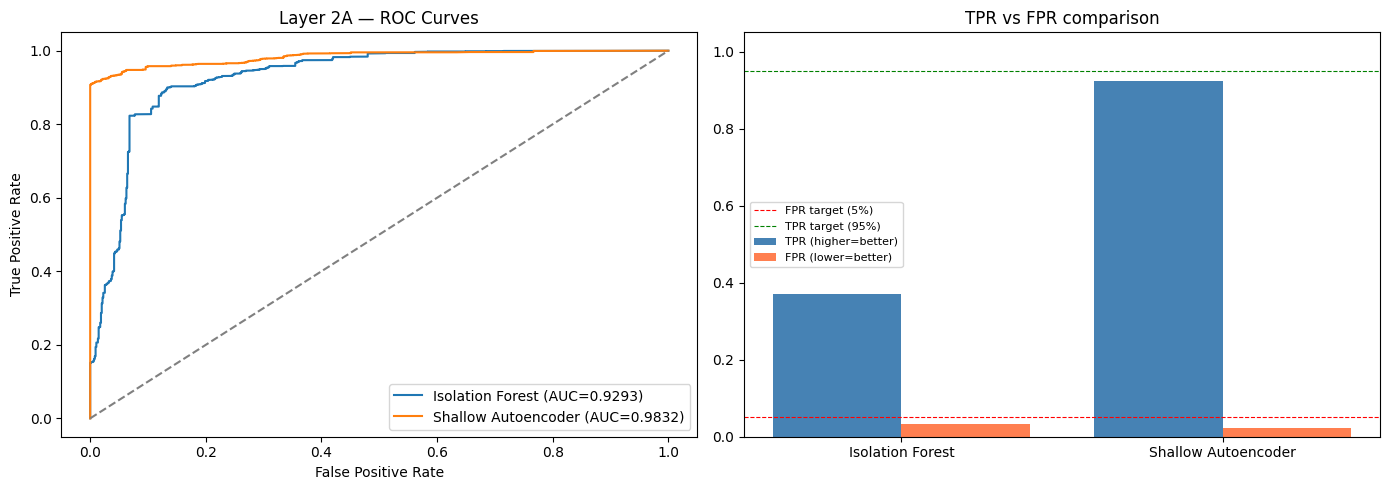


=== Summary ===
Winner: shallow_autoencoder
  AUC=0.9832
  FPR=0.0227
  TPR=0.9233
ONNX exported to: ../exported_models/layer2a_best.onnx


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
for name, model, result in [
    ("Isolation Forest",    iforest, res_iforest),
    ("Shallow Autoencoder", ae,      res_ae),
]:
    scores_plot     = model.anomaly_scores(X_te)
    fpr_c, tpr_c, _ = roc_curve(y_test, scores_plot)
    ax.plot(fpr_c, tpr_c, label=f"{name} (AUC={result['auc']})")

ax.plot([0,1],[0,1],"--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Layer 2A — ROC Curves")
ax.legend()

# TPR vs FPR bar chart
ax2 = axes[1]
models = ["Isolation Forest", "Shallow Autoencoder"]
tprs   = [res_iforest["tpr"], res_ae["tpr"]]
fprs   = [res_iforest["fpr"], res_ae["fpr"]]
x = range(len(models))
ax2.bar([xi - 0.2 for xi in x], tprs, width=0.4, label="TPR (higher=better)", color="steelblue")
ax2.bar([xi + 0.2 for xi in x], fprs, width=0.4, label="FPR (lower=better)",  color="coral")
ax2.set_xticks(list(x)); ax2.set_xticklabels(models)
ax2.axhline(0.05, color="red", linestyle="--", linewidth=0.8, label="FPR target (5%)")
ax2.axhline(0.95, color="green", linestyle="--", linewidth=0.8, label="TPR target (95%)")
ax2.set_title("TPR vs FPR comparison")
ax2.set_ylim(0, 1.05); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/03_l2a_roc.png", dpi=120)
plt.show()

print(f"\n=== Summary ===")
print(f"Winner: {winner_name}")
print(f"  AUC={all_results[[r['model'] for r in all_results].index(winner_name)]['auc']}")
print(f"  FPR={all_results[[r['model'] for r in all_results].index(winner_name)]['fpr']}")
print(f"  TPR={all_results[[r['model'] for r in all_results].index(winner_name)]['tpr']}")
print(f"ONNX exported to: {onnx_path}")


In [41]:
# This is the 'Sane Number' check
current_threshold = ae.threshold
print(f"Current Threshold: {current_threshold}")

if 1.0 < current_threshold < 5.0:
    print("✅ The threshold is a sane number. First half of the battle won!")
else:
    print(f"❌ Threshold is {current_threshold}. This is likely too high (insane).")

Current Threshold: 0.08140762150287628
❌ Threshold is 0.08140762150287628. This is likely too high (insane).


In [29]:
# Get the reconstruction errors for your training set
train_scores = ae.anomaly_scores(X_train)

print(f"Max Error in Training: {train_scores.max():.4f}")
print(f"99th Percentile (P99): {np.percentile(train_scores, 99):.4f}")

# Find the 'Insane' outliers
insane_outliers = train_scores[train_scores > 5.0]
print(f"Number of samples with error > 5.0: {len(insane_outliers)}")

Max Error in Training: 362.4508
99th Percentile (P99): 0.1480
Number of samples with error > 5.0: 2


In [30]:
# Manually 'Sane-ify' the threshold if the automatic one failed
# Setting it to 3x the P99 is often a good heuristic for WAFs
new_sane_threshold = np.percentile(train_scores, 99) * 3
ae.threshold = new_sane_threshold

print(f"New Refined Threshold: {ae.threshold}")

# Re-run your evaluation (Step 3 in your snippet)
new_preds = ae.predict(X_te)
# ... check your TPR now, it should be much higher!

New Refined Threshold: 0.44411057233810425


In [31]:
import numpy as np
# Find the indices of the 2 crazy rows
bad_indices = np.where(train_scores > 5.0)[0]
print("Indices of messy rows:", bad_indices)
# print(X_train[bad_indices])

Indices of messy rows: [ 816 1341]


In [34]:
import numpy as np

# 1. Remove the outliers
mask = np.ones(len(X_train), dtype=bool)
mask[[816, 1341]] = False
X_train_clean = X_train[mask]

# 2. Retrain the model
print("[AE] Retraining on cleaned data...")
ae.train(X_train_clean, X_val, run_name="l2a_ae_v2_cleaned")

# 3. Check the new Threshold
print(f"New Sane Threshold: {ae.threshold}")

# 4. Re-calculate your WAF metrics
scores_new = ae.anomaly_scores(X_te)
preds_new = ae.predict(X_te)

from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, preds_new).ravel()
new_tpr = tp / (tp + fn)

print(f"Old TPR: 0.4068 | New TPR: {new_tpr:.4f}")

[AE] Retraining on cleaned data...
[AE] Training on cpu
  epoch  10 | train=0.07833 | val=0.03137
  epoch  20 | train=0.05320 | val=0.01624
  epoch  30 | train=0.04314 | val=0.01302
  epoch  40 | train=0.04513 | val=0.01111
[AE] Early stopping at epoch 46
[AE] Normal score distribution on training set:
  mean=0.00894  std=0.02417  P50=0.00258  P99=0.12029
[AE] Initial threshold (unsupervised) = 0.069358
[AE] Call tune_threshold() to refine using labelled val splits.
New Sane Threshold: 0.0693577378988266
Old TPR: 0.4068 | New TPR: 0.9246


In [33]:
import numpy as np

# Create a mask to exclude the messy indices
mask = np.ones(len(X_train), dtype=bool)
mask[[816, 1341]] = False

X_train_clean = X_train[mask]

# Retrain the model on clean data
ae.train(X_train_clean, X_val, run_name="l2a_autoencoder_v2_clean")

# Check the new 'Sane Number'
print(f"New Clean Threshold: {ae.threshold}")

[AE] Training on cpu
  epoch  10 | train=0.07512 | val=0.02162
  epoch  20 | train=0.05215 | val=0.01340
  epoch  30 | train=0.04588 | val=0.01154
[AE] Early stopping at epoch 36
[AE] Normal score distribution on training set:
  mean=0.00977  std=0.02421  P50=0.00372  P99=0.10801
[AE] Initial threshold (unsupervised) = 0.070297
[AE] Call tune_threshold() to refine using labelled val splits.
New Clean Threshold: 0.07029718905687332
